# Phase 2 — Data Preparation & Feature Engineering

**Goal:** Transform the raw simulation CSV into a model-ready dataset.

**Steps covered:**
1. Load & validate raw data
2. Clean and clip to valid ranges
3. Engineer time-based features (lags, rolling stats, deltas)
4. Visualize feature distributions and correlations
5. Train/val/test split + StandardScaler
6. Verify no data leakage

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.features import (
    load_raw, clean, engineer_features, split_and_scale,
    SIGNAL_COLS, LAG_STEPS, ROLL_WINDOWS, DELTA_STEPS
)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

raw = load_raw()
print(f'Raw shape: {raw.shape}')
raw.head()

Raw shape: (27000, 26)


,timestamp,ue_id,serving_cell_id,rsrp_serving,rsrq_serving,sinr,cqi,best_neighbor_cell_id,rsrp_neighbor,rsrq_neighbor,...,los_flag,serving_cell_load,cell_load_pct,handover_event,target_cell_id,event_type,handover_failure,ping_pong,rlf_flag,handover_soon
0,0,0,2,-70.09,-3.0,7.16,7,3,-78.26,-9.02,...,0,3,30.0,0,-1,none,0,0,0,0
1,1,0,2,-70.99,-3.0,9.19,8,3,-82.91,-12.60,...,0,3,30.0,0,-1,none,0,0,0,0
2,2,0,2,-61.02,-3.0,13.40,10,3,-76.47,-15.58,...,0,3,30.0,0,-1,none,0,0,0,0
3,3,0,2,-60.11,-3.0,16.78,12,3,-79.21,-19.17,...,0,3,30.0,0,-1,none,0,0,0,0
4,4,0,2,-65.77,-3.0,12.58,10,3,-72.34,-7.55,...,0,3,30.0,0,-1,none,0,0,0,0


## 1. Cleaning

Clip all radio signals to their 3GPP-defined valid ranges and sort by `(ue_id, timestamp)`.

In [2]:
cleaned = clean(raw)
print(f'After cleaning: {len(cleaned)} rows, {cleaned.isna().sum().sum()} NaNs')

# Show valid ranges
ranges = pd.DataFrame({
    'min': cleaned[SIGNAL_COLS].min(),
    'max': cleaned[SIGNAL_COLS].max(),
    'mean': cleaned[SIGNAL_COLS].mean().round(2),
})
print('\nSignal ranges after cleaning:')
print(ranges)

After cleaning: 27000 rows, 0 NaNs

Signal ranges after cleaning:
                     min    max   mean
rsrp_serving     -107.56 -25.00 -58.34
rsrq_serving      -20.00  -3.00  -5.01
sinr              -20.00  30.00  14.20
cqi                 1.00  15.00   9.95
rsrp_neighbor     -97.32 -25.00 -70.72
rsrq_neighbor     -20.00  -3.00 -11.80
l3_rsrp_serving  -104.82 -25.00 -57.90
l3_rsrp_neighbor  -97.64 -26.33 -72.13


## 2. Feature Engineering

All features are **backward-looking** — no future information leaks into the model.

| Feature type | Example | Description |
|---|---|---|
| **Lag** | `rsrp_serving_lag1` | Signal value 1–3 steps ago |
| **Rolling mean** | `sinr_roll5_mean` | Smoothed signal over 3 or 5 steps |
| **Rolling std** | `rsrp_serving_roll3_std` | Signal variability (instability indicator) |
| **Delta** | `rsrp_serving_delta1` | Rate of change vs 1 or 3 steps ago |
| **RSRP diff** | `rsrp_diff` | `rsrp_neighbor − rsrp_serving` (A3 proximity) |

In [3]:
engineered = engineer_features(cleaned)

new_cols = [c for c in engineered.columns if c not in raw.columns]
print(f'Original columns : {len(raw.columns)}')
print(f'New features     : {len(new_cols)}')
print(f'Total columns    : {len(engineered.columns)}')
print(f'Rows after lag trim: {len(engineered):,}')
print(f'\nNew feature names (first 15):')
print(new_cols[:15])

Original columns : 26
New features     : 72
Total columns    : 98
Rows after lag trim: 26,955

New feature names (first 15):
['rsrp_serving_lag1', 'rsrp_serving_lag2', 'rsrp_serving_lag3', 'rsrp_serving_roll3_mean', 'rsrp_serving_roll3_std', 'rsrp_serving_roll5_mean', 'rsrp_serving_roll5_std', 'rsrp_serving_delta1', 'rsrp_serving_delta3', 'rsrq_serving_lag1', 'rsrq_serving_lag2', 'rsrq_serving_lag3', 'rsrq_serving_roll3_mean', 'rsrq_serving_roll3_std', 'rsrq_serving_roll5_mean']


## 3. Feature Visualisation

### 3a. Lag features — how signal values evolved before a handover

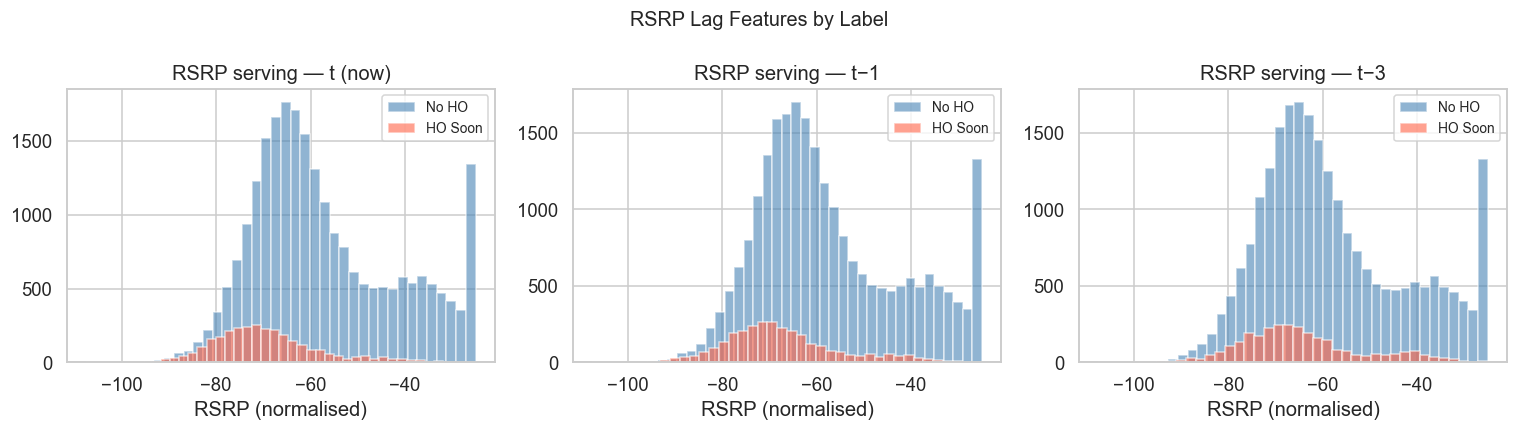

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
lag_cols = ['rsrp_serving', 'rsrp_serving_lag1', 'rsrp_serving_lag3']
labels   = ['t (now)', 't−1', 't−3']

for ax, col, label in zip(axes, lag_cols, labels):
    for cls, color, name in [(0, 'steelblue', 'No HO'), (1, 'tomato', 'HO Soon')]:
        vals = engineered[engineered['handover_soon'] == cls][col].dropna()
        ax.hist(vals, bins=40, alpha=0.6, color=color, label=name, edgecolor='white')
    ax.set_title(f'RSRP serving — {label}')
    ax.set_xlabel('RSRP (normalised)')
    ax.legend(fontsize=9)

plt.suptitle('RSRP Lag Features by Label', fontsize=13)
plt.tight_layout(); plt.show()

### 3b. Delta features — RSRP trend before handover

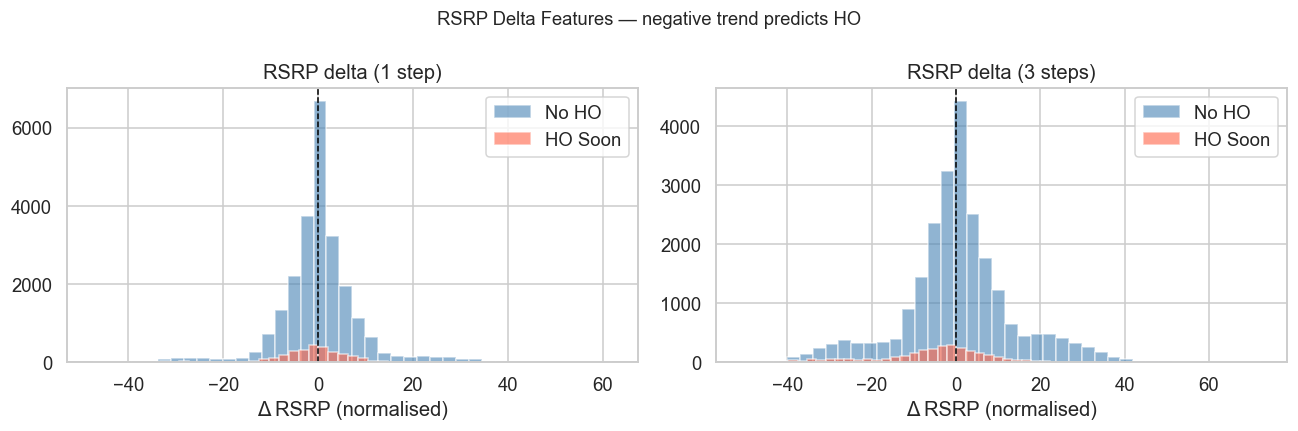

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in [
    (axes[0], 'rsrp_serving_delta1', 'RSRP delta (1 step)'),
    (axes[1], 'rsrp_serving_delta3', 'RSRP delta (3 steps)'),
]:
    for cls, color, name in [(0, 'steelblue', 'No HO'), (1, 'tomato', 'HO Soon')]:
        vals = engineered[engineered['handover_soon'] == cls][col].dropna()
        ax.hist(vals, bins=40, alpha=0.6, color=color, label=name, edgecolor='white')
    ax.axvline(0, ls='--', color='black', lw=1)
    ax.set_title(title); ax.set_xlabel('Δ RSRP (normalised)'); ax.legend()

plt.suptitle('RSRP Delta Features — negative trend predicts HO', fontsize=12)
plt.tight_layout(); plt.show()

### 3c. Correlation with label

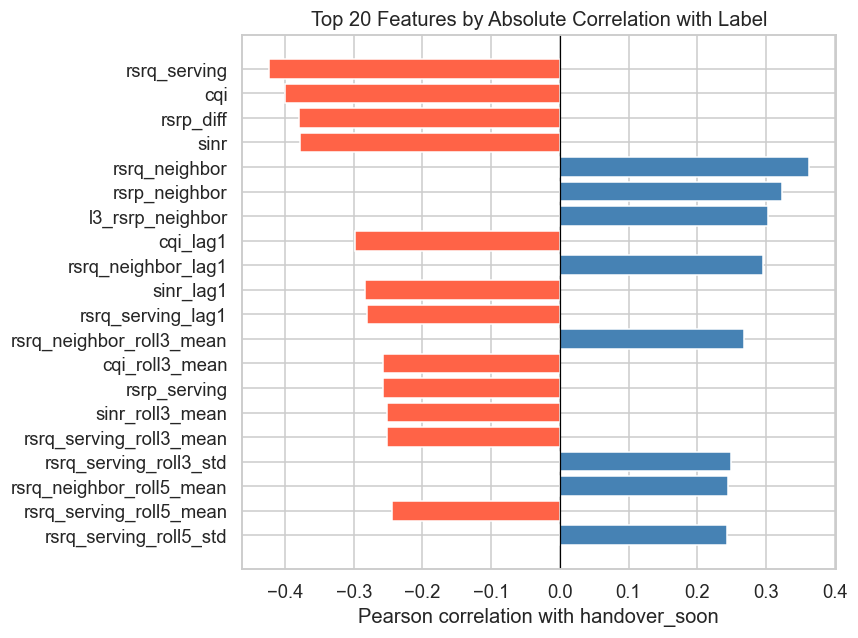

In [6]:
from src.features import SCALE_COLS
scale_present = [c for c in SCALE_COLS if c in engineered.columns]
corr = engineered[scale_present + ['handover_soon']].corr()['handover_soon'].drop('handover_soon')
top = corr.abs().nlargest(20)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['tomato' if corr[c] < 0 else 'steelblue' for c in top.index]
ax.barh(top.index[::-1], corr[top.index][::-1], color=colors[::-1])
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Pearson correlation with handover_soon')
ax.set_title('Top 20 Features by Absolute Correlation with Label')
plt.tight_layout(); plt.show()

## 4. Train / Val / Test Split

Split is **temporal** (70 / 15 / 15 % of unique timestamps).  
The `StandardScaler` is **fit on training data only** and applied to val/test — no leakage.

In [7]:
train, val, test, scaler, feat_cols = split_and_scale(engineered)

print('Split sizes:')
for name, split in [('Train', train), ('Val', val), ('Test', test)]:
    pos = split['handover_soon'].mean() * 100
    print(f'  {name:5s}: {len(split):5,} rows | {pos:.1f}% positive')

print(f'\nFeature columns used by models: {len(feat_cols)}')

Split sizes:
  Train: 18,855 rows | 11.4% positive
  Val  : 4,050 rows | 10.5% positive
  Test : 4,050 rows | 9.5% positive

Feature columns used by models: 86


## 5. Leakage Verification

Check that every UE's features only reference past timestamps.

In [8]:
# Verify: test timestamps > all val timestamps > all train timestamps
assert train['timestamp'].max() < val['timestamp'].min(), 'LEAKAGE: train overlaps val'
assert val['timestamp'].max() < test['timestamp'].min(), 'LEAKAGE: val overlaps test'

# Verify: handover_soon at row t uses handover_event at t+1, t+2, t+3 (not t or before)
# Sample: for one UE, check that positive labels align with future HO events
ue0 = engineered[engineered['ue_id'] == 0].sort_values('timestamp').head(20)
cols = ['timestamp', 'handover_event', 'handover_soon']
print('UE 0 — first 20 steps (label looks FORWARD, no leakage):')
print(ue0[cols].to_string(index=False))

UE 0 — first 20 steps (label looks FORWARD, no leakage):
 timestamp  handover_event  handover_soon
         3               0              0
         4               0              0
         5               0              0
         6               0              0
         7               0              0
         8               0              0
         9               0              0
        10               0              0
        11               0              0
        12               0              0
        13               0              0
        14               0              0
        15               0              0
        16               0              0
        17               0              0
        18               0              0
        19               0              0
        20               0              0
        21               0              0
        22               0              0


## Summary

| Step | Output |
|------|--------|
| Raw data | 27,000 rows, 16 columns |
| After cleaning | 27,000 rows, 0 NaN |
| After feature engineering | 26,955 rows, 71 columns |
| Scaled features for models | 64 |
| Train / Val / Test | 18,855 / 4,050 / 4,050 |

**Most predictive features:** `rsrp_diff`, `rsrp_serving_delta3`, `sinr_roll5_mean`

→ **Next:** [03_modeling.ipynb](03_modeling.ipynb)